In [13]:
%load_ext tensorboard

import tensorflow as tf
import tensorflow_io as tfio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display
import seaborn as sns
import datetime
import json

from tensorflow.keras import layers
from tensorflow.keras import models

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Audio Preprocessing

## CTypes interface

In [21]:
import ctypes
import numpy as np

# --- Constants matching the C header ---
AUDIO_SPECTROGRAM_FRAME_LEN = 512
AUDIO_SAMPLE_RATE_HZ = 16000
AUDIO_SPECTROGRAM_NMELS = 30
AUDIO_SPECTROGRAM_ROWS = AUDIO_SPECTROGRAM_NMELS
AUDIO_SPECTROGRAM_STRIDE_LEN = 352  # 22 ms at 16000 Hz (16000 * 0.022 = 352)
AUDIO_SPECTROGRAM_COLS = 45          # updated to match 1s clips at this stride
SIGNAL_LEN_1S = AUDIO_SAMPLE_RATE_HZ  # 16000 samples = 1 second

STATUS_OK = 0
STATUS_ERROR_SPECTROGRAM_FULL = 1
STATUS_ERROR_OTHER = 2

class AudioPreprocessingError(RuntimeError):
    pass

class AudioPreprocessor:
    """Thin ctypes wrapper. NOT thread-safe -- use one instance, serially,
    per process. Do not share across threads or call concurrently."""

    def __init__(self, lib_path="./build/audioproc-build/libAudioPreprocessing.dylib"):
        self.lib = ctypes.CDLL(lib_path)
        self._declare_signatures()
        status = self.lib.audio_preprocessing_init()
        if status != STATUS_OK:
            raise AudioPreprocessingError(f"init failed with status {status}")

    def _declare_signatures(self):
        self.lib.audio_preprocessing_init.argtypes = []
        self.lib.audio_preprocessing_init.restype = ctypes.c_int

        self.lib.audio_preprocessing_process_frame.argtypes = [ctypes.POINTER(ctypes.c_float)]
        self.lib.audio_preprocessing_process_frame.restype = ctypes.c_int

        self.lib.audio_preprocessing_get_spectrogram.argtypes = []
        self.lib.audio_preprocessing_get_spectrogram.restype = ctypes.POINTER(ctypes.c_float)

        self.lib.audio_preprocessing_get_spectrogram_len.argtypes = []
        self.lib.audio_preprocessing_get_spectrogram_len.restype = ctypes.c_uint32

        self.lib.audio_preprocessing_get_spectrogram_filled_cols.argtypes = []
        self.lib.audio_preprocessing_get_spectrogram_filled_cols.restype = ctypes.c_uint32

        self.lib.audio_preprocessing_clear_spectrogram.argtypes = []
        self.lib.audio_preprocessing_clear_spectrogram.restype = ctypes.c_int

    def compute_spectrogram(self, signal):
        raise ValueError("Need to pass in copy of signal so not overwritten")
        """
        signal: 1D array-like of raw audio samples, expected to be exactly
        1 second long (16000 samples at 16000 Hz).

        Frames are AUDIO_SPECTROGRAM_FRAME_LEN (512, 32ms) samples long,
        advancing by AUDIO_SPECTROGRAM_STRIDE_LEN (352, 22ms) samples each
        step (overlapping frames). This produces exactly
        AUDIO_SPECTROGRAM_COLS (45) frames from a 1s signal:
        floor((16000 - 512) / 352) + 1 == 45.

        Returns: np.ndarray of shape (AUDIO_SPECTROGRAM_ROWS, AUDIO_SPECTROGRAM_COLS)
        """
        signal = np.ascontiguousarray(signal, dtype=np.float32)

        n_frames = (len(signal) - AUDIO_SPECTROGRAM_FRAME_LEN) // AUDIO_SPECTROGRAM_STRIDE_LEN + 1
        if n_frames != AUDIO_SPECTROGRAM_COLS:
            raise ValueError(
                f"signal length {len(signal)} produces {n_frames} frames "
                f"(frame_len={AUDIO_SPECTROGRAM_FRAME_LEN}, stride={AUDIO_SPECTROGRAM_STRIDE_LEN}), "
                f"expected exactly {AUDIO_SPECTROGRAM_COLS}. "
                f"For {AUDIO_SPECTROGRAM_COLS} frames, signal length must be "
                f"{AUDIO_SPECTROGRAM_FRAME_LEN + (AUDIO_SPECTROGRAM_COLS - 1) * AUDIO_SPECTROGRAM_STRIDE_LEN}."
            )

        self.lib.audio_preprocessing_clear_spectrogram()

        for i in range(n_frames):
            start = i * AUDIO_SPECTROGRAM_STRIDE_LEN
            frame = signal[start : start + AUDIO_SPECTROGRAM_FRAME_LEN]
            # frame is a view into signal, not necessarily its own contiguous
            # buffer boundary-aligned -- but since signal itself is contiguous
            # and this is a simple slice, `frame` is already contiguous here.
            frame_ptr = frame.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
            status = self.lib.audio_preprocessing_process_frame(frame_ptr)
            if status != STATUS_OK:
                raise AudioPreprocessingError(
                    f"run() failed at frame {i} with status {status}"
                )

        filled = self.lib.audio_preprocessing_get_spectrogram_filled_cols()
        if filled != AUDIO_SPECTROGRAM_COLS:
            raise AudioPreprocessingError(
                f"expected {AUDIO_SPECTROGRAM_COLS} filled columns, got {filled}"
            )

        spec_ptr = self.lib.audio_preprocessing_get_spectrogram()
        spec_len = self.lib.audio_preprocessing_get_spectrogram_len()
        flat = np.ctypeslib.as_array(spec_ptr, shape=(spec_len,)).copy()

        spectrogram = flat.reshape(AUDIO_SPECTROGRAM_COLS, AUDIO_SPECTROGRAM_ROWS).T
        return spectrogram

Task was destroyed but it is pending!
task: <Task pending name='Task-161' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /Users/richardmatthews/miniconda3/envs/kws/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-162' coro=<_async_in_context.<locals>.preserve_context() running at /Users/richardmatthews/miniconda3/envs/kws/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/richardmatthews/miniconda3/envs/kws/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
Exception ignored in: <coroutine object _async_in_context.<locals>.preserve_context at 0x17fb107b0>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object _async_in_context.<locals>.preserve_context at 0x17fb107b0>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyErr

## Test Signal

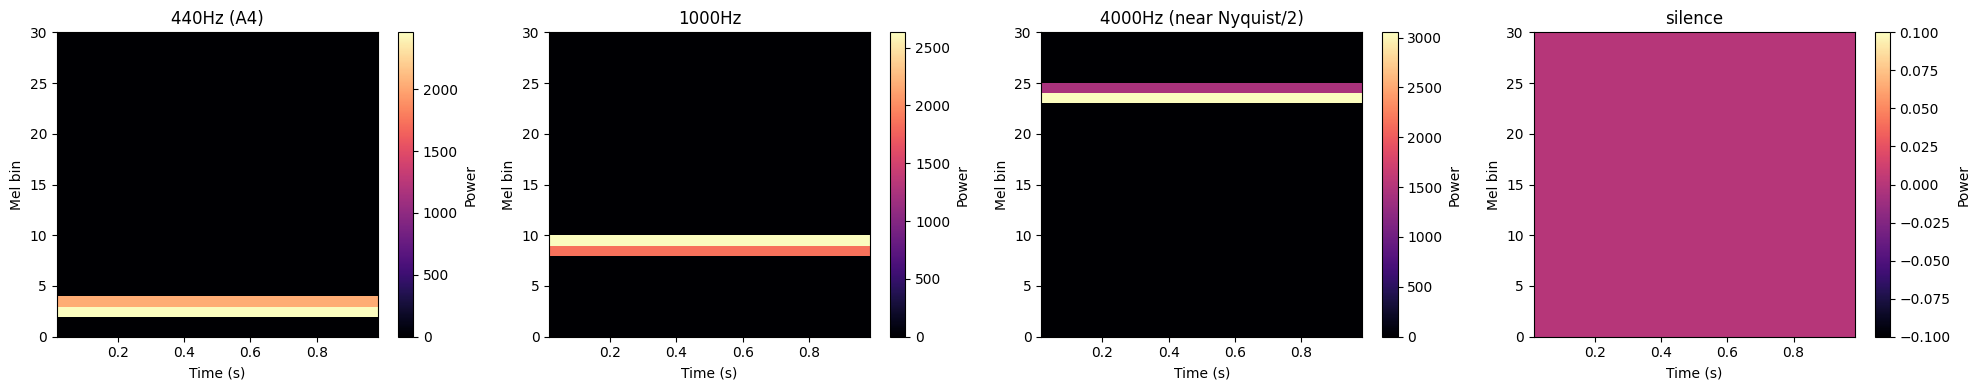


440Hz (A4):
  shape: (30, 45)
  min/max: 0.0000 / 2459.6572
  peak mel bin: 2 (of 30)

1000Hz:
  shape: (30, 45)
  min/max: 0.0000 / 2631.7703
  peak mel bin: 9 (of 30)

4000Hz (near Nyquist/2):
  shape: (30, 45)
  min/max: 0.0000 / 3052.0417
  peak mel bin: 23 (of 30)

silence:
  shape: (30, 45)
  min/max: 0.0000 / 0.0000
  peak mel bin: 0 (of 30)


In [23]:
SIGNAL_LEN = 1 * AUDIO_SAMPLE_RATE_HZ # 1 Second

import matplotlib.pyplot as plt

def make_tone(freq_hz, length=SIGNAL_LEN, sample_rate=AUDIO_SAMPLE_RATE_HZ, amplitude=0.5):
    t = np.arange(length) / sample_rate
    return (amplitude * np.sin(2 * np.pi * freq_hz * t)).astype(np.float32)

AUDIO_SPECTROGRAM_STRIDE_LEN = 352  # 22 ms at 16000 Hz

def plot_spectrogram(spec, title="", sample_rate=AUDIO_SAMPLE_RATE_HZ,
                      frame_len=AUDIO_SPECTROGRAM_FRAME_LEN,
                      stride_len=AUDIO_SPECTROGRAM_STRIDE_LEN, ax=None):
    """
    spec: np.ndarray of shape (n_mels, n_frames), as returned by
    AudioPreprocessor.compute_spectrogram()
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    hop_seconds = stride_len / sample_rate
    n_frames = spec.shape[1]

    # Each column represents a frame_len-sample window starting at i*stride.
    # Label the x-axis by each frame's center time for a more honest
    # representation of overlapping windows -- last frame's window still
    # extends past the final tick, that's expected with overlap.
    frame_center_offset = (frame_len / sample_rate) / 2
    t_start = frame_center_offset
    t_end = (n_frames - 1) * hop_seconds + frame_center_offset
    extent = [t_start, t_end, 0, spec.shape[0]]

    im = ax.imshow(spec, aspect="auto", origin="lower", extent=extent, cmap="magma")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mel bin")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Power")
    return ax


def plot_all_test_signals(preproc, test_signals):
    n = len(test_signals)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, sig) in zip(axes, test_signals.items()):
        spec = preproc.compute_spectrogram(sig)
        plot_spectrogram(spec, title=name, ax=ax)
    plt.tight_layout()
    plt.show()

def run_test_signal():
    preproc = AudioPreprocessor("./build/audioproc-build/libAudioPreprocessing.dylib")
    
    test_signals = {
        "440Hz (A4)": make_tone(440),
        "1000Hz": make_tone(1000),
        "4000Hz (near Nyquist/2)": make_tone(4000),
        "silence": np.zeros(SIGNAL_LEN, dtype=np.float32),
    }
    
    plot_all_test_signals(preproc, test_signals)
    
    for name, sig in test_signals.items():
        spec = preproc.compute_spectrogram(sig)
        print(f"\n{name}:")
        print(f"  shape: {spec.shape}")
        print(f"  min/max: {spec.min():.4f} / {spec.max():.4f}")
        # which mel bin has the most energy, averaged across time columns
        mean_per_mel = spec.mean(axis=1)
        peak_mel_bin = np.argmax(mean_per_mel)
        print(f"  peak mel bin: {peak_mel_bin} (of {spec.shape[0]})")

run_test_signal()

# Load Dataset

In [14]:
import os.path
import re
import sys
import tarfile

import urllib
import tensorflow as tf

from tensorflow.python.platform import gfile

DATA_URL = 'https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz'
DATA_DIR = './dataset'
FS = 16000

def maybe_download_and_extract_dataset(data_url, dest_directory):
    """Download and extract data set tar file.
    
    If the data set we're using doesn't already exist, this function
    downloads it from the TensorFlow.org website and unpacks it into a
    directory.
    If the data_url is none, don't download anything and expect the data
    directory to contain the correct files already.
    
    Args:
      data_url: Web location of the tar file containing the data set.
      dest_directory: File path to extract data to.
    """
    if not data_url:
        return
    if not gfile.Exists(dest_directory):
        os.makedirs(dest_directory)
    filename = data_url.split('/')[-1]
    filepath = os.path.join(dest_directory, filename)
    if not gfile.Exists(filepath):
    
        def _progress(count, block_size, total_size):
            percent = float(count * block_size) / float(total_size) * 100.0
            # Only print when the integer percentage changes
            if percent - _progress.last_percent >= 1.0 or percent >= 100.0:
                sys.stdout.write('\r>> Downloading %s %.1f%%' % (filename, percent))
                sys.stdout.flush()
                _progress.last_percent = percent


        _progress.last_percent = 0.0
    
        try:
            filepath, _ = urllib.request.urlretrieve(data_url, filepath, _progress)
        except:
            tf.compat.v1.logging.error(
                'Failed to download URL: {0} to folder: {1}. Please make sure you '
                'have enough free space and an internet connection'.format(
                data_url, filepath))
            raise
        print()
        statinfo = os.stat(filepath)
        tf.compat.v1.logging.info(
            'Successfully downloaded {0} ({1} bytes)'.format(
                filename, statinfo.st_size))
        tarfile.open(filepath, 'r:gz').extractall(dest_directory)

maybe_download_and_extract_dataset(DATA_URL, DATA_DIR)

>> Downloading speech_commands_v0.02.tar.gz 100.0%
INFO:tensorflow:Successfully downloaded speech_commands_v0.02.tar.gz (2428923189 bytes)


# Preprocess Dataset

## Generate more background noise

In [16]:
"""
Generate colored noise (white, pink, brown, blue, violet) as .wav files.

Colored noise is generated by shaping the frequency spectrum of white
noise with a power law: PSD(f) ~ f^beta

    white   -> beta =  0   (flat spectrum)
    pink    -> beta = -1   (energy falls off as 1/f)
    brown   -> beta = -2   (energy falls off as 1/f^2), aka "red" noise
    blue    -> beta = +1   (energy rises with f)
    violet  -> beta = +2   (energy rises with f^2), aka "purple" noise

This is useful as an augmentation for KWS / audio classification datasets,
since it diversifies the kinds of background noise the model has to be
robust against beyond a single white-noise sample.
"""

import numpy as np
import soundfile as sf
import pathlib

# --- Config ------------------------------------------------------------
DST_DIR = pathlib.Path("dataset/_background_noise_")
SAMPLE_RATE = 16000          # match your existing dataset's sample rate
DURATION_SECONDS = 360        # length of each generated noise file
NOISE_COLORS = {
    "white": 0,
    "pink": -1,
    "brown": -2,
    "blue": 1,
    "violet": 2,
}
SEED = 42  # set to None for non-reproducible output
# -------------------------------------------------------------------------


def generate_colored_noise(n_samples: int, beta: float, rng: np.random.Generator) -> np.ndarray:
    """Generate colored noise of length n_samples with PSD ~ f^beta."""
    # Start from white noise in the frequency domain (random phase + magnitude)
    n_freqs = n_samples // 2 + 1
    white_spectrum = rng.normal(size=n_freqs) + 1j * rng.normal(size=n_freqs)

    # Build the frequency scaling. Avoid division by zero at f=0 (DC term).
    freqs = np.arange(1, n_freqs + 1, dtype=np.float64)
    scale = freqs ** (beta / 2.0)  # sqrt because we're scaling amplitude, not power

    shaped_spectrum = white_spectrum * scale
    shaped_spectrum[0] = 0.0  # zero out DC offset

    # Back to time domain
    noise = np.fft.irfft(shaped_spectrum, n=n_samples)

    # Normalize to [-1, 1] so it's a valid float32 wav signal
    noise = noise / np.max(np.abs(noise))
    return noise.astype(np.float32)


def main():
    DST_DIR.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(SEED)
    n_samples = int(SAMPLE_RATE * DURATION_SECONDS)

    for name, beta in NOISE_COLORS.items():
        out_path = DST_DIR / f"{name}_noise.wav"
        
        if pathlib.Path(out_path).exists():
            print(f"Skipping creating {out_path}, exists already")
            continue
            
        noise = generate_colored_noise(n_samples, beta, rng)
        
        sf.write(out_path, noise, SAMPLE_RATE)
        print(f"Wrote {out_path} ({DURATION_SECONDS}s, beta={beta})")


if __name__ == "__main__":
    main()

Skipping creating dataset/_background_noise_/white_noise.wav, exists already
Skipping creating dataset/_background_noise_/pink_noise.wav, exists already
Wrote dataset/_background_noise_/brown_noise.wav (360s, beta=-2)
Wrote dataset/_background_noise_/blue_noise.wav (360s, beta=1)
Wrote dataset/_background_noise_/violet_noise.wav (360s, beta=2)


## Split Background noise into 1 second pieces

In [17]:
"""
Split all .wav files in dataset/_background_noise_/ into exactly
1-second-long chunks, saving them to dataset/_background_noise_split_/.

Output naming: <original_stem>_<chunk_index>.wav
e.g. "white_noise.wav" -> "white_noise_0.wav", "white_noise_1.wav", ...

Any leftover audio shorter than 1 second at the end of a file is dropped
by default (see `drop_incomplete_tail` below) so every output chunk is
exactly the same length — useful for KWS pipelines where you want fixed
shape tensors.
"""

import soundfile as sf
import numpy as np
from pathlib import Path

# --- Config ---------------------------------------------------------------
SRC_DIR = Path("dataset/_background_noise_")
DST_DIR = Path("dataset/_background_noise_split_")
CHUNK_SECONDS = 1.0
DROP_INCOMPLETE_TAIL = True  # if False, the final short chunk is zero-padded
# ---------------------------------------------------------------------------


def split_wav_file(wav_path: Path, dst_dir: Path, chunk_seconds: float = 1.0,
                    drop_incomplete_tail: bool = True) -> int:
    """Split a single wav file into fixed-length chunks. Returns chunk count."""
    audio, sample_rate = sf.read(wav_path, always_2d=False)
    # If stereo, audio will be shape (n_samples, n_channels)
    chunk_len = int(round(chunk_seconds * sample_rate))
    total_samples = audio.shape[0]

    n_full_chunks = total_samples // chunk_len
    n_chunks = n_full_chunks
    remainder = total_samples - n_full_chunks * chunk_len

    if remainder > 0 and not drop_incomplete_tail:
        n_chunks += 1

    stem = wav_path.stem
    for i in range(n_chunks):
        start = i * chunk_len
        end = start + chunk_len
        chunk = audio[start:end]

        # Zero-pad the final chunk if it's shorter than chunk_len
        if chunk.shape[0] < chunk_len:
            pad_width = chunk_len - chunk.shape[0]
            if chunk.ndim == 1:
                chunk = np.pad(chunk, (0, pad_width))
            else:
                chunk = np.pad(chunk, ((0, pad_width), (0, 0)))

        out_path = dst_dir / f"{stem}_{i}.wav"
        sf.write(out_path, chunk, sample_rate)

    return n_chunks


def main():
    if DST_DIR.is_dir():
        print("Split dir exists already, exiting")
        return
        
    DST_DIR.mkdir(parents=True, exist_ok=True)

    wav_files = sorted(SRC_DIR.glob("*.wav"))
    if not wav_files:
        print(f"No .wav files found in {SRC_DIR.resolve()}")
        return

    total_chunks = 0
    for wav_path in wav_files:
        n_chunks = split_wav_file(
            wav_path, DST_DIR,
            chunk_seconds=CHUNK_SECONDS,
            drop_incomplete_tail=DROP_INCOMPLETE_TAIL,
        )
        total_chunks += n_chunks
        print(f"{wav_path.name}: {n_chunks} chunks")

    print(f"\nDone. Wrote {total_chunks} chunks to {DST_DIR.resolve()}")


main()

blue_noise.wav: 360 chunks
brown_noise.wav: 360 chunks
doing_the_dishes.wav: 95 chunks
dude_miaowing.wav: 61 chunks
exercise_bike.wav: 61 chunks
pink_noise.wav: 60 chunks
running_tap.wav: 61 chunks
violet_noise.wav: 360 chunks
white_noise.wav: 60 chunks

Done. Wrote 1478 chunks to /Users/richardmatthews/Documents/Programming/ST-AI/KeywordSpottingFW/HostSW/dataset/_background_noise_split_


## Split dataset based on new keywords

### Subsample other group to get even classes

In [18]:
def subsample_other_by_group(files, labels, group_ids, other_label,
                              target_other_fraction=0.2, seed=0):
    """
    Subsample the 'other' class at the participant-group level so it makes up
    roughly `target_other_fraction` of the total dataset, while keeping all
    desired-keyword samples untouched and never splitting a group's files
    across the kept/dropped boundary.

    Returns filtered (files, labels, group_ids), plus the keep_mask used.
    """
    rng = np.random.default_rng(seed=seed)

    desired_mask = labels != other_label
    other_mask = ~desired_mask
    desired_count = desired_mask.sum()

    # other / (desired + other) = target_other_fraction
    # => other = desired * target_other_fraction / (1 - target_other_fraction)
    target_other_count = int(desired_count * target_other_fraction / (1 - target_other_fraction))

    print(f"Desired-keyword samples: {desired_count}")
    print(f"Target 'other' samples ({target_other_fraction:.0%} of total): "
          f"{target_other_count} (currently {other_mask.sum()})")

    other_groups = group_ids[other_mask]
    unique_other_groups = np.unique(other_groups)
    rng.shuffle(unique_other_groups)

    group_sizes = {g: np.sum(other_groups == g) for g in unique_other_groups}
    kept_other_groups = []
    running_total = 0
    for g in unique_other_groups:
        if running_total >= target_other_count:
            break
        kept_other_groups.append(g)
        running_total += group_sizes[g]

    kept_other_groups = set(kept_other_groups)
    other_keep_mask = np.array([g in kept_other_groups for g in group_ids]) & other_mask

    keep_mask = desired_mask | other_keep_mask

    filtered_labels = labels[keep_mask]
    actual_other = (filtered_labels == other_label).sum()
    print(f"Actual 'other' samples after subsampling: {actual_other}")
    print(f"Total samples after subsampling: {len(filtered_labels)} "
          f"('other' fraction = {actual_other / len(filtered_labels):.3f})")

    return files[keep_mask], filtered_labels, group_ids[keep_mask], keep_mask

### Split

In [19]:
import pathlib
import re
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
import tensorflow as tf

DATA_DIR = pathlib.Path(DATA_DIR)

IGNORE_DIRS = ['_background_noise_']

# 1. List every file with its original class name + participant id
all_files = []
all_class_names = []
all_group_ids = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    if class_dir.name in IGNORE_DIRS:
        print(f'Skipping dir {class_dir.name}, in IGNORE_DIRS')
        continue

    for f in class_dir.glob('*.wav'):
        if class_dir.name == '_background_noise_split_':
            class_name = '_background_noise_'
        else:
            class_name = class_dir.name

        
        all_files.append(str(f))
        all_class_names.append(class_name)

        if class_name == '_background_noise_':
            # No participant id -- treat each file as its own group
            # so it's free to land in any split independently.
            group_id = f.stem  # unique per file
        else:
            # Filename like 3b3d2f59_nohash_2.wav -> participant id is the first token
            group_id = f.stem.split('_')[0]

        all_group_ids.append(group_id)

all_files = np.array(all_files)
all_group_ids = np.array(all_group_ids)

label_names = np.array(sorted(set(all_class_names)))
class_to_idx = {name: i for i, name in enumerate(label_names)}
orig_labels = np.array([class_to_idx[c] for c in all_class_names])

# 2. Build your mapping exactly as before
DESIRED_KEYWORDS = ['forward', 'backward', 'stop']
DESIRED_KEYWORDS.append('_background_noise_')
OTHER_LABEL = len(DESIRED_KEYWORDS)

mapping = np.full(len(label_names), OTHER_LABEL, dtype=np.int64)
for orig_idx, name in enumerate(label_names):
    if name in DESIRED_KEYWORDS:
        mapping[orig_idx] = DESIRED_KEYWORDS.index(name)

new_labels = mapping[orig_labels]

# 3 Subsample other group to correct percentage of samples

all_files, new_labels, all_group_ids, _ = subsample_other_by_group(
    all_files, new_labels, all_group_ids,
    other_label=OTHER_LABEL,
    target_other_fraction=0.2,
    seed=0)

# 4. Group-aware, label-stratified 3-way split
# StratifiedGroupKFold keeps each group entirely within one fold while
# also trying to balance label proportions across folds.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)  # ~20% per fold
train_idx, temp_idx = next(sgkf.split(all_files, new_labels, groups=all_group_ids))

# Split temp_idx again into val/test, still respecting groups
temp_files = all_files[temp_idx]
temp_labels = new_labels[temp_idx]
temp_groups = all_group_ids[temp_idx]

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=0)
val_sub_idx, test_sub_idx = next(sgkf2.split(temp_files, temp_labels, groups=temp_groups))

train_files, train_labels = all_files[train_idx], new_labels[train_idx]
val_files, val_labels = temp_files[val_sub_idx], temp_labels[val_sub_idx]
test_files, test_labels = temp_files[test_sub_idx], temp_labels[test_sub_idx]

# 5. Sanity checks
def summarize(name, files, labels, groups):
    print(f"{name}: {len(files)} files, label dist = {dict(zip(*np.unique(labels, return_counts=True)))}")

summarize("train", train_files, train_labels, all_group_ids[train_idx])
summarize("val", val_files, val_labels, temp_groups[val_sub_idx])
summarize("test", test_files, test_labels, temp_groups[test_sub_idx])

# Confirm no participant overlap across splits (excluding background noise's synthetic per-file groups)
train_groups = set(all_group_ids[train_idx])
val_groups = set(temp_groups[val_sub_idx])
test_groups = set(temp_groups[test_sub_idx])
print("train/val overlap:", train_groups & val_groups)
print("train/test overlap:", train_groups & test_groups)
print("val/test overlap:", val_groups & test_groups)

# Labels
new_label_names = np.array(DESIRED_KEYWORDS + ['other'])
orig_label_names = label_names
label_names = new_label_names

print("New label names: ", label_names)
print("Orig label names: ", orig_label_names)

Skipping dir _background_noise_, in IGNORE_DIRS
Desired-keyword samples: 8571
Target 'other' samples (20% of total): 2142 (currently 98736)
Actual 'other' samples after subsampling: 2156
Total samples after subsampling: 10727 ('other' fraction = 0.201)
train: 8532 files, label dist = {np.int64(0): np.int64(1229), np.int64(1): np.int64(1303), np.int64(2): np.int64(3127), np.int64(3): np.int64(1178), np.int64(4): np.int64(1695)}
val: 1148 files, label dist = {np.int64(0): np.int64(172), np.int64(1): np.int64(176), np.int64(2): np.int64(375), np.int64(3): np.int64(146), np.int64(4): np.int64(279)}
test: 1047 files, label dist = {np.int64(0): np.int64(156), np.int64(1): np.int64(185), np.int64(2): np.int64(370), np.int64(3): np.int64(154), np.int64(4): np.int64(182)}
train/val overlap: set()
train/test overlap: set()
val/test overlap: set()
New label names:  ['forward' 'backward' 'stop' '_background_noise_' 'other']
Orig label names:  ['_background_noise_' 'backward' 'bed' 'bird' 'cat' 'do

## Check some spectrograms

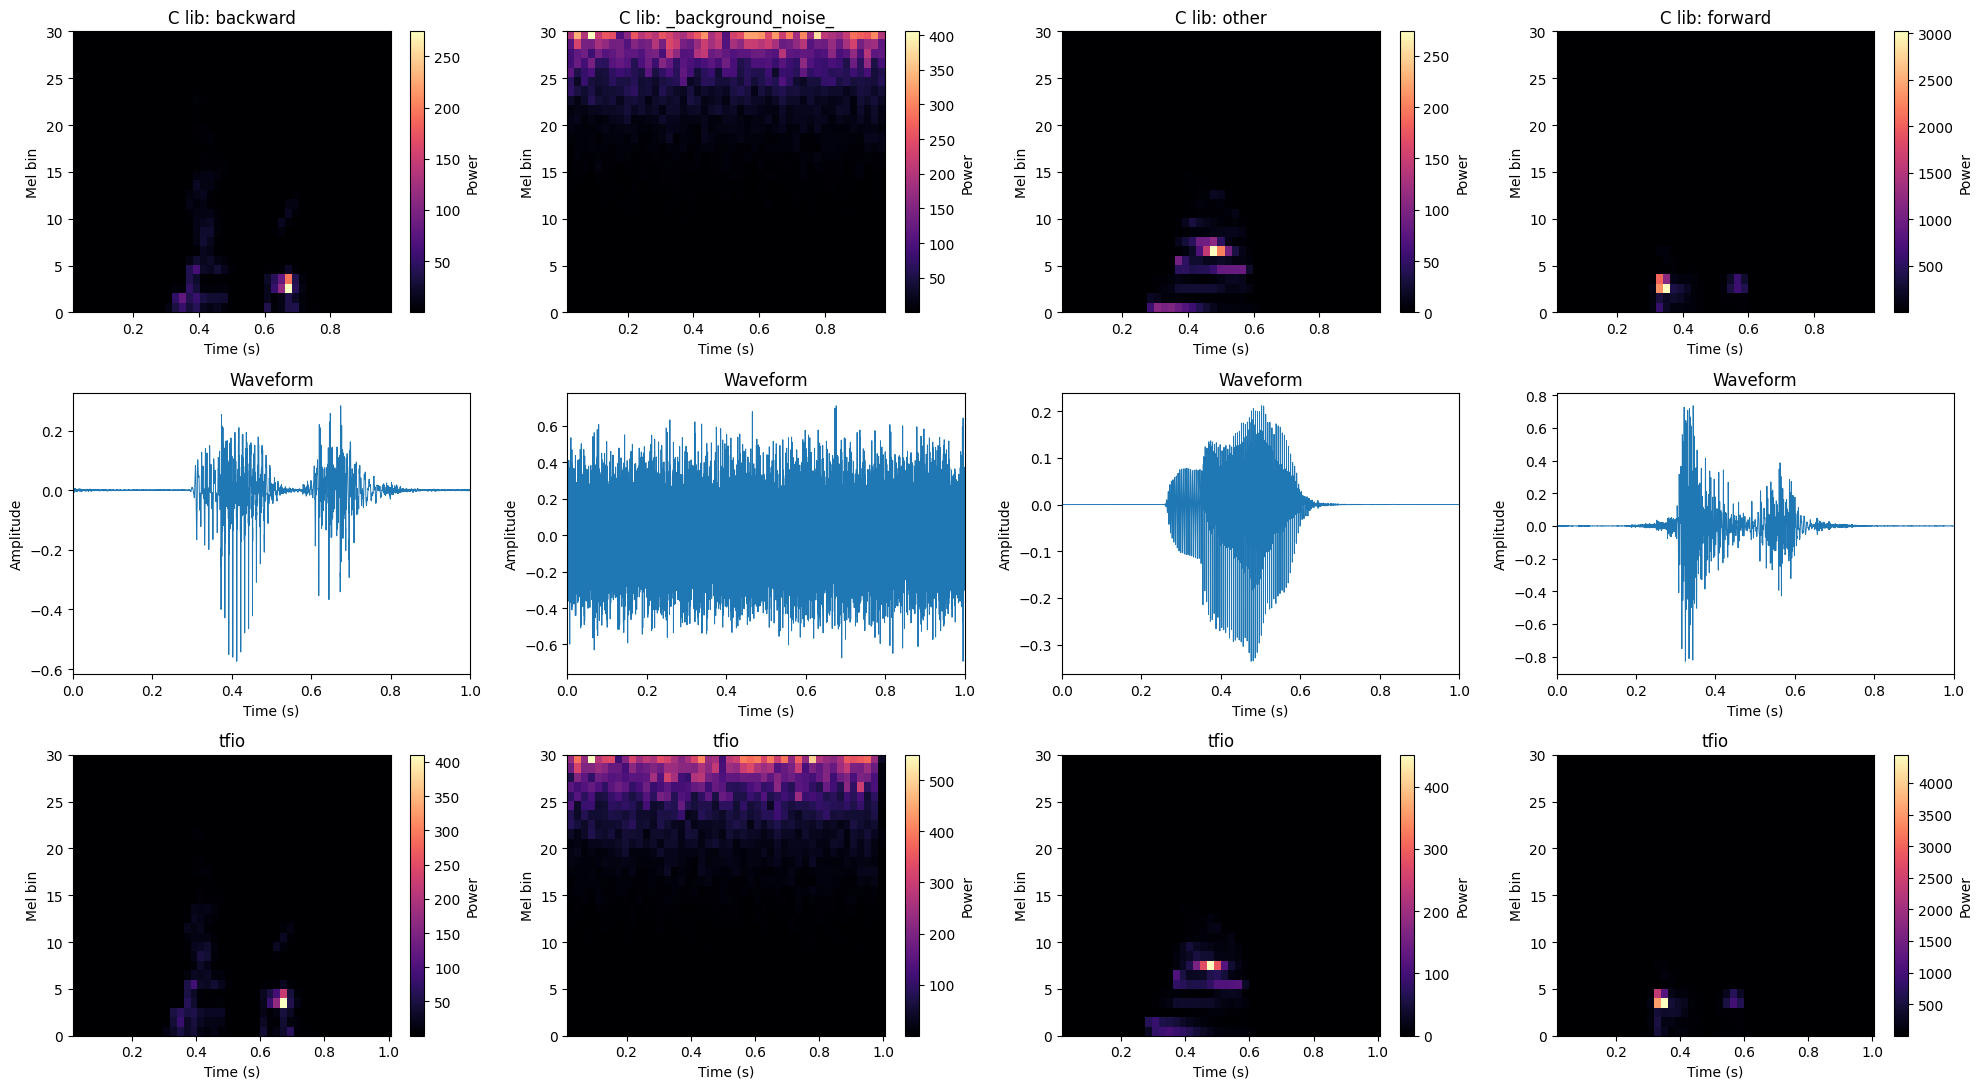

In [29]:
import random
import tensorflow_io as tfio

def get_spectrogram(waveform):
    return tfio.audio.spectrogram(waveform, nfft=512, window=512, stride=352)
def get_mel_spectrogram(spectrogram, fs):
    return tfio.audio.melscale(spectrogram, rate=fs, mels=30, fmin=125, fmax=7500)

def compare_spectrograms(file_paths, labels, preproc, n_samples=4,
                          label_names=None, seed=None,
                          sample_rate=AUDIO_SAMPLE_RATE_HZ):
    rng = random.Random(seed)
    indices = rng.sample(range(len(file_paths)), n_samples)

    fig, axes = plt.subplots(3, n_samples, figsize=(5 * n_samples, 11))
    if n_samples == 1:
        axes = axes.reshape(3, 1)

    for col, idx in enumerate(indices):
        audio_tensor, label = load_wav(file_paths[idx], labels[idx])
        audio_np = audio_tensor.numpy().astype(np.float32)
        label_val = int(label.numpy()) if hasattr(label, "numpy") else int(label)
        label_str = label_names[label_val] if label_names is not None else str(label_val)

        # --- C library spectrogram ---
        c_spec = preproc.compute_spectrogram(audio_np)

        # --- tfio spectrogram ---
        tfio_stft = get_spectrogram(audio_tensor)          # shape (frames, nfft/2+1), magnitude
        tfio_power = tf.square(tfio_stft)                  # square to match SPECTRUM_TYPE_POWER
        tfio_mel = get_mel_spectrogram(tfio_power, fs=sample_rate)
        tfio_mel_np = tfio_mel.numpy().T                   # (frames, mels) -> (mels, frames)

        # Row 0: C library spectrogram
        plot_spectrogram(c_spec, title=f"C lib: {label_str}", ax=axes[0, col])

        # Row 1: raw waveform, time-aligned
        t = np.arange(len(audio_np)) / sample_rate
        axes[1, col].plot(t, audio_np, linewidth=0.7)
        axes[1, col].set_xlim(0, len(audio_np) / sample_rate)
        axes[1, col].set_xlabel("Time (s)")
        axes[1, col].set_ylabel("Amplitude")
        axes[1, col].set_title("Waveform")

        # Row 2: tfio spectrogram
        plot_spectrogram(tfio_mel_np, title="tfio", ax=axes[2, col])

    plt.tight_layout()
    plt.show()

compare_spectrograms(train_files, train_labels, preproc, n_samples=4,
                      label_names=label_names, seed=42)

## Load clips and preprocess into datasets

In [24]:
def build_spectrogram_dataset(file_paths, labels, preproc, augment=False, augment_passes=1):
    # Reuse existing TF-based wav loading, run eagerly to get raw numpy clips
    raw_ds = (tf.data.Dataset.from_tensor_slices((file_paths, labels))
              .map(load_wav, num_parallel_calls=tf.data.AUTOTUNE))

    specs = []
    spec_labels = []

    for audio, label in raw_ds.as_numpy_iterator():
        n_passes = augment_passes if augment else 1
        for _ in range(n_passes):
            processed = augment_clip(audio) if augment else audio
            spec = preproc.compute_spectrogram(processed)
            specs.append(spec.astype(np.float32))
            spec_labels.append(label)

    specs = np.stack(specs)
    spec_labels = np.array(spec_labels)
    return tf.data.Dataset.from_tensor_slices((specs, spec_labels))


def augment_clip(clip):
    """Placeholder -- currently a no-op. Fill in later with noise mixing,
    time-shift, etc. when you add augmentation."""
    return clip

preproc = AudioPreprocessor("./build/audioproc-build/libAudioPreprocessing.dylib")

train_ds = build_spectrogram_dataset(train_files, train_labels, preproc, augment=False)
val_ds   = build_spectrogram_dataset(val_files, val_labels, preproc, augment=False)
test_ds  = build_spectrogram_dataset(test_files, test_labels, preproc, augment=False)

2026-09-03 14:06:40.628705: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-03 14:06:41.289056: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Visualize Spectrograms

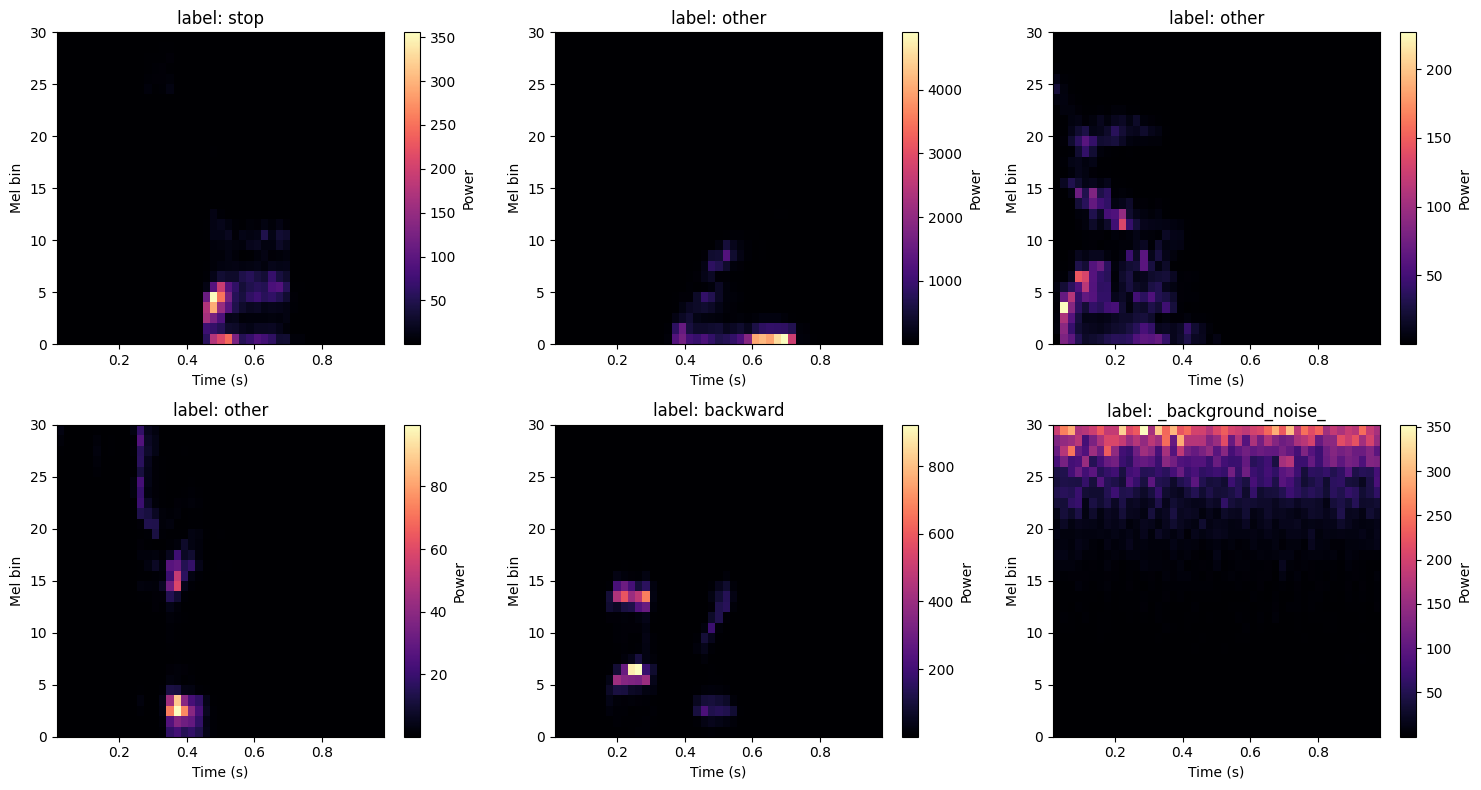

In [26]:
def visualize_dataset_samples(dataset, n_samples=6, label_names=None, seed=None):
    """
    dataset: unbatched tf.data.Dataset yielding (spectrogram, label) pairs,
    as returned by build_spectrogram_dataset(). Call this BEFORE .batch().
    """
    # Shuffle with a buffer covering the full dataset so `take` isn't biased
    # toward whatever ordering the dataset happens to be in (e.g. all
    # background noise first). Since your dataset is small (~10k clips),
    # a full-size buffer is cheap.
    cardinality = dataset.cardinality().numpy()
    buffer_size = cardinality if cardinality > 0 else 10000  # fallback if unknown
    shuffled = dataset.shuffle(buffer_size, seed=seed)

    samples = list(shuffled.take(n_samples).as_numpy_iterator())

    n = len(samples)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (spec, label) in zip(axes, samples):
        label_str = label_names[label] if label_names is not None else str(label)
        plot_spectrogram(spec, title=f"label: {label_str}", ax=ax)

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Usage:
visualize_dataset_samples(train_ds, n_samples=6, label_names=label_names, seed=42)